In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
from pathlib import Path
from IPython.display import Audio
import IPython.display as ipd
from scipy.io import wavfile
import tempfile
import os
import librosa
import pandas as pd
import seaborn as sns
import h5py
import mne
from scipy.stats import zscore
from matplotlib.lines import Line2D
from mne_bids import BIDSPath, read_raw_bids
from matplotlib_venn import venn2,venn2_circles
from tqdm import tqdm

In [2]:
cm = 1/2.54
plt.rcParams['svg.fonttype'] = 'none'

fontdict = dict(fontsize=7)
fontsize = 7

red = '#A9373B'
blue = '#2369BD'
orange = '#CC8963'
green = '#009944'

stg_color = '#20B2AA'
smc_color = '#6A5ACD'
insula_color = '#D4AF37'

reds = sns.light_palette(red, as_cmap=True)
blues = sns.light_palette(blue, as_cmap=True)
oranges = sns.light_palette(orange, as_cmap=True)
greens = sns.light_palette(green, as_cmap=True)

recon_dir = '/cwork/ns458/ECoG_Recon/'
mne.viz.set_3d_backend('notebook')
# text svg

Using notebook 3d backend.


# Decode phoneme and articulator

In [7]:
from scipy.ndimage import gaussian_filter1d

ref = 'bipolar'

task = 'LexicalDelay'
decode_type = 'phoneme'

result_path = BIDSPath(
    datatype=f'(decode)(resolved){decode_type}',
    root= f'../results/{task}(roi)({ref})',
    suffix='highgamma',
    check=False
)

full_path = result_path.match()

scores = []

for path in full_path:
    mat = h5py.File(path, 'r')
    # accuracy: (time, fold)
    accuracy = mat['accuracy'][()]
    # time: (time,)
    time = mat['time'][()]
    # p_value: (time,)
    p_value = mat['p_values'][()]
    # baseline: (time, fold, n_perm)
    baseline = mat['baseline'][()]
    mat.close()

    n_time, n_fold = accuracy.shape

    # ---- 1) baseline 在 perm 维度上平均 → (time, fold) ----
    baseline_mean = baseline.mean(axis=-1)  # shape: (time, fold)

    # ---- 2) 宽表：每列一个 fold（accuracy）----
    sigma = 2  # 单位：time 采样点数（不是秒）；你可以调 1~5 之类
    accuracy = gaussian_filter1d(accuracy, sigma=sigma, axis=0, mode="nearest")
    df_acc = pd.DataFrame(accuracy, index=time, columns=range(n_fold)).reset_index()
    df_acc = df_acc.rename(columns={'index': 'time'})

    # 宽表 baseline
    df_base = pd.DataFrame(baseline_mean, index=time, columns=range(n_fold)).reset_index()
    df_base = df_base.rename(columns={'index': 'time'})

    # ---- 3) 宽 → 长，显式保留 fold ----
    df_acc = df_acc.melt(
        id_vars='time',
        var_name='fold',
        value_name='accuracy'
    )  # (time * fold, 3)

    df_base = df_base.melt(
        id_vars='time',
        var_name='fold',
        value_name='baseline'
    )

    # 合并 accuracy 和 baseline（按 time, fold 对齐）
    df = df_acc.merge(df_base, on=['time', 'fold'], how='left')

    # ---- 4) p_value 只有 time 维度，就按 time merge ----
    df_p = pd.DataFrame({'time': time, 'p_value': p_value})
    df = df.merge(df_p, on='time', how='left')

    # ---- 5) 加上 path 的元信息 ----
    hemi = 'Left' if path.subject[-1]=='l' else 'Right'
    roi = path.subject[:-1]
    df['roi'] = roi
    df['phase'] = path.processing
    df['hemi'] = hemi
    df['description'] = path.description
    df['phoneme'] = path.recording
    df['datatype'] = path.datatype.replace('(decode)(resolving)', '')
    df['band'] = path.suffix

    scores.append(df)

scores = pd.concat(scores, ignore_index=True)
# scores = scores[scores.roi.isin(['INS','STG','SMC'])]
scores = scores[scores.description=='Repeat']
# scores = scores[scores.phoneme=='1']
scores.head()

,time,fold,accuracy,baseline,p_value,roi,phase,hemi,description,phoneme,datatype,band
455,-0.30,0,0.310186,0.168194,0.059701,AIC,Delay,Left,Repeat,None,(decode)(resolved)phoneme,highgamma
456,-0.28,0,0.280450,0.172778,0.562189,AIC,Delay,Left,Repeat,None,(decode)(resolved)phoneme,highgamma
457,-0.26,0,0.250580,0.165347,0.119403,AIC,Delay,Left,Repeat,None,(decode)(resolved)phoneme,highgamma
458,-0.24,0,0.225310,0.157431,0.333333,AIC,Delay,Left,Repeat,None,(decode)(resolved)phoneme,highgamma
459,-0.22,0,0.206355,0.171458,0.502488,AIC,Delay,Left,Repeat,None,(decode)(resolved)phoneme,highgamma


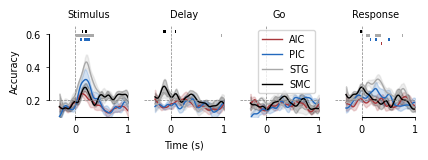

In [9]:
hue_order = ['AIC', 'PIC', 'STG','SMC']
hemis = ['Left']
phases = ['Stimulus', 'Delay', 'Go', 'Response']

fig, axes = plt.subplots(1, len(phases), figsize=(3*len(phases)*cm, 3*len(hemis)*cm))

time_arr = scores['time'].unique()
time_arr.sort()

ymax, pad, bar_h = 0.5, 0.03, 0.02
chance = 1/5
ymin = 0.1

colors = [red, blue, 'darkgray','black']

for j, phase in enumerate(phases):
    ax = axes[j]
    
    legend = True if j == 2 else False
    
    subset = scores[(scores.phase == phase) & (scores.hemi == hemi)]
    sns.lineplot(
        data=subset,
        x='time', y='accuracy', hue='roi',
        palette=colors, hue_order=hue_order,
        lw=1,
        ax=ax, legend=legend
    )
    
    # significant cluster（每个 roi 一个 bar）
    for k, roi in enumerate(hue_order):
        roi_data = subset[(subset.roi == roi) & (subset.fold == 1)].sort_values('time')
        if roi_data.empty:
            continue
        mask = (roi_data['p_value'].values < 0.01)
        offset = k * (bar_h + 0.005)
        
        if mask.any():
            ax.fill_between(
                roi_data['time'].values,
                ymax + pad + offset,
                ymax + pad + bar_h + offset,
                where=mask,
                color=colors[k],
                alpha=1,
                step='mid',
                linewidth=0
            )

for j, phase in enumerate(phases):
    ax = axes[j]
    ax.tick_params(labelsize=7, width=0.5, length=2)
    plt.setp(ax.spines.values(), linewidth=0.75)
    ax.axvline(x=0, color='gray', linestyle='--', lw=0.5)
    ax.axhline(y=chance, color='gray', linestyle='--', lw=0.5)
    ax.set_xlim(-0.5, 1)
    ax.set_ylim(ymin, ymax + pad + len(hue_order)*(bar_h + 0.005) + 0.02)
    ax.set_xlabel('')
    ax.set_ylabel('')
    
    # 右列去掉 y 轴
    if j == 1:
        ax.set_yticks([])
        ax.spines['left'].set_visible(False)
    
    # 顶行加标题
    ax.set_title(phase.capitalize(), fontsize=7)
    
    # 左列加 hemi 标签
    if j == 0:
        ax.set_ylabel('Accuracy', fontsize=7)

axes[1].set_xlabel('Time (s)', fontsize=7)
axes[2].legend(fontsize=7)

for ax in fig.axes:
    sns.despine(ax=ax, trim=True, offset=0.2)

# remove y spine for rightmost axes
for ax in axes[1:].flatten():
    ax.spines['left'].set_visible(False)
    ax.set_yticks([])
    ax.set_ylabel('')

# plt.tight_layout()
fig.savefig(f'../img/fig3/fig3_{task}_{decode_type}.svg', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# load HGA data
task ='PhonemeSequence'
ref = 'bipolar'
hga_paths = BIDSPath(
            root=f'../results/{task}({ref})',
            datatype='HGA',
            suffix='time',  # 注意这里改成 'time'
            check=False,
        ).match()

# 2. 筛选 perception 和 passive 的数据
HGAs = []
for path in tqdm(hga_paths):
    df = pd.read_csv(path)
    # 只保留 perception 或 passive
    HGAs.append(df)

HGAs = pd.concat(HGAs)
coords = HGAs.drop(columns=['time', 'value']).drop_duplicates()
HGAs.head()

100%|██████████| 226/226 [00:03<00:00, 65.38it/s]


,time,channel,value,mask,roi,hemi,subject,description,task,phase,modality,label,x,y,z
0,-1.0,D0019_ROG13-14,-0.043502,False,mOccG,R,D0019,Repeat,PhonemeSequence,Audio,sound,ctx_rh_G_occipital_middle,41.472074,-88.150203,-3.545099
1,-1.0,D0019_RIIH5-6,-0.054793,False,OPC,R,D0019,Repeat,PhonemeSequence,Audio,sound,ctx_rh_Pole_occipital,11.886836,-94.046488,10.403848
2,-1.0,D0019_ROG4-5,-0.025007,False,sOccG,R,D0019,Repeat,PhonemeSequence,Audio,sound,ctx_rh_G_occipital_sup,16.298644,-91.860079,29.446276
3,-1.0,D0019_ROG18-19,-0.083139,False,Intersection,R,D0019,Repeat,PhonemeSequence,Audio,sound,Intersection,41.531682,-78.171196,19.605156
4,-1.0,D0019_RLSO7-8,-0.040828,False,PhG,R,D0019,Repeat,PhonemeSequence,Audio,sound,ctx_rh_G_oc-temp_med-Parahip,18.457267,-10.274114,-31.949923


### Windowed decoding

In [6]:
ref = 'bipolar'

decode_type = 'articulator'
task = 'PhonemeSequence'

decode_path = BIDSPath(
    datatype=f'(decode){decode_type}',
    root= f'../results/{task}(roi)({ref})',
    suffix='highgamma',
    check=False
).match()

scores = []

for path in decode_path:
    mat = h5py.File(path, 'r')
    # (n_folds,)
    acc = mat['accuracy'][()]
    # 可能是标量，也可能是 (n_folds,)
    p_value = mat['p_value'][()]
    # (n_folds, n_perm)
    perm_scores = mat['perm_scores'][()]
    mat.close()

    n_folds = acc.shape[0]

    hemi = 'Left' if path.subject[-1]=='l' else 'Right'
    roi = path.subject[:-1]

    # 如果 p_value 是标量，就扩展成长度为 n_folds 的向量
    p_value_arr = np.array(p_value)
    if p_value_arr.shape == ():
        p_value_arr = np.repeat(p_value_arr, n_folds)

    # 这里我示例用 perm_scores 每个 fold 的平均
    perm_mean = perm_scores.mean(axis=1)  # (n_folds,)

    df = pd.DataFrame({
        'fold': np.arange(n_folds),        # 0,1,2,... 每个 fold 一行
        'score': acc,
        'p_value': p_value_arr,
        'perm': perm_mean,
        'roi': roi,
        'hemi': hemi,
        'description': path.description,
        'datatype': path.datatype.replace('(decode)', ''),
        'phase': path.processing,
        'band': path.suffix,
    })

    scores.append(df)

scores = pd.concat(scores, ignore_index=True)

scores.head()

,fold,score,p_value,perm,roi,hemi,description,datatype,phase,band
0,0,0.285714,0.178218,0.247143,AIC,Left,Repeat,articulator,Delay,highgamma
1,1,0.142857,0.178218,0.256667,AIC,Left,Repeat,articulator,Delay,highgamma
2,2,0.380952,0.178218,0.240952,AIC,Left,Repeat,articulator,Delay,highgamma
3,3,0.333333,0.178218,0.248571,AIC,Left,Repeat,articulator,Delay,highgamma
4,4,0.238095,0.178218,0.260000,AIC,Left,Repeat,articulator,Delay,highgamma


/hpc/home/ns458/coganlab/nanlinshi/tmp/ipykernel_691341/2585505097.py:23: UserWarning: The palette list has more values (2) than needed (1), which may not be intended.
  sns.barplot(


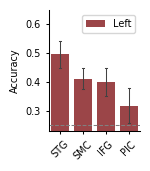

In [29]:
# ① 先算每个 (roi, hemi) 的平均 score

phase = 'Delay'

roi_hemi_mean = (
    scores[(scores.phase==phase) & (scores.p_value<0.05) & (scores.hemi=='Left')]
    .groupby(['roi', 'hemi'], as_index=False)['score']
    .mean()
)

# ② 再算每个 roi 的平均分（跨 hemi），用于排序
roi_order = (
    roi_hemi_mean
    .groupby('roi', as_index=False)['score']
    .mean()
    .sort_values('score') 
    .iloc[::-1]# 从低到高；想从高到低就加 .iloc[::-1]
    ['roi']
    .tolist()
)

fig, ax = plt.subplots(figsize=(3*cm, 4*cm))
sns.barplot(
    data=scores[(scores.phase==phase) & (scores.p_value<0.05) & (scores.hemi=='Left')],
    x='roi',
    y='score',
    hue='hemi',          
    order=roi_order,
    lw=1.5, capsize=0.1,
    palette=[red, blue],
    err_kws={'linewidth': .75},   
    dodge=True,
    alpha=1
)

ax.axhline(y=1/4, color='gray', linestyle='--', linewidth=.75)
for ax in fig.axes:
    ax.tick_params(labelsize=7, width=.75, length=2, which='both',)
    plt.setp(ax.spines.values(), linewidth=.75)
    ax.set_ylabel('Accuracy')
    ax.set_xlabel('')
    ax.set_ylim(0.23, 0.65)
    # remove top and right spines
    sns.despine()
    
ax.set_ylabel('Accuracy', fontsize=7)
ax.legend(title='', fontsize=7)
plt.xticks(rotation=45)

plt.savefig(f'../img/fig3/phoneme_window_decoding_{phase}.svg', dpi=300, bbox_inches='tight')
plt.show()

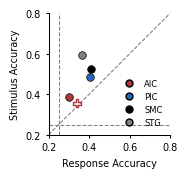

In [10]:
# 按 (roi, hemi) 分别计算 perception 和 production 的平均 score
id_cols = ['roi', 'hemi']

per = scores[(scores.phase == 'Stimulus') & (scores.p_value<0.05)].groupby(id_cols)['score'].mean()
pro = scores[(scores.phase == 'Response') & (scores.p_value<0.05)].groupby(id_cols)['score'].mean()

wide = pd.concat({'perception': per, 'production': pro}, axis=1).dropna().reset_index()

wide = wide[wide.roi.isin(['AIC', 'PIC', 'SMC', 'STG'])]
# 颜色映射
roi_colors = dict(zip(['AIC', 'PIC', 'SMC', 'STG'], [red, blue, 'black', 'gray']))

fig, ax = plt.subplots(figsize=(5*cm, 5*cm))

left = wide[wide.hemi == 'Left']
for _, row in left.iterrows():
    ax.scatter(row['production'], row['perception'], 
               c=roi_colors[row['roi']], s=30, edgecolor='k', linewidth=0.5)

# 右脑：空心点（虚线边框）
right = wide[wide.hemi == 'Right']
for _, row in right.iterrows():
    ax.scatter(row['production'], row['perception'],marker='P',
               facecolors='none', edgecolors=roi_colors[row['roi']], 
               s=30, linewidth=1,)

# 对角线和 chance level
lim = (0.2, 0.8)
ax.plot(lim, lim, ls='--', c='gray', lw=0.75, zorder=0)
ax.axvline(x=1/4, ls='--', c='gray', lw=0.75)
ax.axhline(y=1/4, ls='--', c='gray', lw=0.75)
ax.set_xlim(lim)
ax.set_ylim(lim)
ax.set_aspect('equal')

ax.set_xlabel('Response Accuracy', fontsize=7)
ax.set_ylabel('Stimulus Accuracy', fontsize=7)

# Legend
handles = [Line2D([0], [0], marker='o', linestyle='', markerfacecolor=c, 
                  markeredgecolor='k', markersize=5, label=r) 
           for r, c in roi_colors.items()]

ax.legend(handles=handles, loc='lower right', fontsize=6, frameon=False)

for ax in fig.axes:
    ax.tick_params(labelsize=7, width=.75, length=2, which='both',)
    plt.setp(ax.spines.values(), linewidth=.75)

sns.despine()
plt.tight_layout()
fig.savefig(f'../img/fig3/fig3_decode_{task}_window.svg', dpi=300, bbox_inches='tight')
plt.show()

In [11]:
# load decoding channels
PHONEME_PATH = '/cwork/ns458/BIDS-1.4_Phoneme_sequencing/BIDS/derivatives'

phase = 'Response'

decoding_pts = BIDSPath(
    root=os.path.join(PHONEME_PATH, 'decoding(bipolar)'),
    processing=phase,
    extension='.h5',
    check=False,
)

pick_coord = []

for roi in hue_order:
    roi_pt = decoding_pts.update(subject=f'{roi}l').match()[0]
    with h5py.File(roi_pt, 'r') as f:
        ch = [c.decode() for c in f['channel'][:]]
        
        df = coords.copy()[coords.channel.isin(ch)]
        df['roi'] = roi
        pick_coord.append(df)
        
pick_coord = pd.concat(pick_coord)
pick_coord.head()

,channel,mask,roi,hemi,subject,description,task,phase,modality,label,x,y,z
7,D0052_LI5-6,False,AIC,L,D0052,Repeat,PhonemeSequence,Audio,sound,ctx_lh_S_circular_insula_sup,-35.562153,3.638421,9.06771
3277,D0052_LI5-6,True,AIC,L,D0052,Repeat,PhonemeSequence,Audio,sound,ctx_lh_S_circular_insula_sup,-35.562153,3.638421,9.06771
10,D0052_LI5-6,False,AIC,L,D0052,Repeat,PhonemeSequence,Go,sound,ctx_lh_S_circular_insula_sup,-35.562153,3.638421,9.06771
3002,D0052_LI5-6,True,AIC,L,D0052,Repeat,PhonemeSequence,Go,sound,ctx_lh_S_circular_insula_sup,-35.562153,3.638421,9.06771
10,D0052_LI5-6,False,AIC,L,D0052,Repeat,PhonemeSequence,Response,sound,ctx_lh_S_circular_insula_sup,-35.562153,3.638421,9.06771


In [ ]:
import numpy as np
import pyvista as pv
import matplotlib.pyplot as plt
from mne.viz import Brain
from scipy.spatial import cKDTree


# ROI 颜色：和 decoding 图保持一致
roi_colors = dict(zip(hue_order, colors))

# 只画左半球电极
pick_coord_lh = pick_coord[pick_coord["hemi"].isin(["L", "lh", "Left"])].copy()
if pick_coord_lh.empty:
    pick_coord_lh = pick_coord[pick_coord["x"] < 0].copy()

cord = pick_coord_lh[["x", "y", "z"]].values
rois = pick_coord_lh["roi"].values

# 加载左半球表面：pial -> inflated（把电极贴到 inflated 上）
lh_pial_path = f"{recon_dir}/fsaverage/surf/lh.pial"
lh_infl_path = f"{recon_dir}/fsaverage/surf/lh.inflated"
lh_coords_pial, _ = mne.read_surface(lh_pial_path)
lh_coords_infl, _ = mne.read_surface(lh_infl_path)
lh_tree = cKDTree(lh_coords_pial)

_, lh_indices = lh_tree.query(cord)
cord_on_infl = lh_coords_infl[lh_indices]

# 创建 inflated 左脑
lh_brain = Brain(
    "fsaverage",
    subjects_dir=recon_dir,
    surf="inflated",
    hemi="lh",
    background="white",
    show=False,
    cortex=(0.95, 0.95, 0.95),
    alpha=0.1,
    size=(600 * cm, 600 * cm),
)

labels = mne.read_labels_from_annot(
    "fsaverage",
    parc="aparc.a2009s",
    hemi="lh",
    subjects_dir=recon_dir,
)
insula_labels = [lab for lab in labels if "insul" in lab.name.lower()]
for lab in insula_labels:
    lh_brain.add_label(lab, borders=False, color=insula_color, alpha=0.4)

# 统一大小，不做大小调整
point_size = 25

# 按 ROI 上色
for roi in hue_order:
    roi_mask = rois == roi
    if not roi_mask.any():
        continue

    cloud = pv.PolyData(cord_on_infl[roi_mask])
    lh_brain._renderer.plotter.add_mesh(
        cloud,
        render_points_as_spheres=True,
        point_size=point_size,
        color=roi_colors[roi],
        lighting=False,
        smooth_shading=False,
        opacity=1,
    )

lh_brain.show_view(view="lateral", distance=400)
lh_brain._renderer.plotter.window_size = [1400, 1400]

fig, ax = plt.subplots(1, 1, figsize=(5 * cm, 5 * cm))
ax.imshow(lh_brain.screenshot(mode="rgb"))
ax.axis("off")
ax.set_title("Left", fontsize=7)

from matplotlib.patches import Patch

legend_elements = [Patch(facecolor=roi_colors[roi], label=roi) for roi in hue_order]
fig.legend(handles=legend_elements, loc="lower center", ncol=len(hue_order), fontsize=7)

lh_brain.close()
fig.savefig(f'../img/fig3/fig3_{task}_spatial.svg', dpi=300, bbox_inches='tight')
plt.show()

# Decoding lexicality

In [8]:
# load HGA data
task ='LexicalDelay'
ref = 'bipolar'
hga_paths = BIDSPath(
            root=f'../results/{task}({ref})',
            datatype='HGA',
            suffix='time',  # 注意这里改成 'time'
            check=False,
        ).match()

# 2. 筛选 perception 和 passive 的数据
HGAs = []
for path in tqdm(hga_paths):
    df = pd.read_csv(path)
    # 只保留 perception 或 passive
    HGAs.append(df)

HGAs = pd.concat(HGAs)
coords = HGAs.drop(columns=['time', 'value']).drop_duplicates()
HGAs.head()

100%|██████████| 512/512 [00:04<00:00, 108.04it/s]


,time,channel,value,mask,roi,hemi,subject,description,task,phase,modality,label,x,y,z
0,-1.0,D0023_RPIF3-4,0.249398,False,Intersection,R,D0023,Decision,LexicalDelay,Audio,sound,Intersection,41.901912,-28.228735,17.149502
1,-1.0,D0023_R2MF2-3,0.051112,False,Intersection,R,D0023,Decision,LexicalDelay,Audio,sound,Intersection,11.195341,-7.769187,33.884895
2,-1.0,D0023_RPSF1-2,0.095070,False,CGs,R,D0023,Decision,LexicalDelay,Audio,sound,ctx_rh_S_pericallosal,6.423360,-15.496811,23.453189
3,-1.0,D0023_RPIF1-2,0.231350,False,Sylvian,R,D0023,Decision,LexicalDelay,Audio,sound,ctx_rh_Lat_Fis-post,35.187262,-26.860379,15.945394
4,-1.0,D0023_RPIF2-3,0.361105,False,Sylvian,R,D0023,Decision,LexicalDelay,Audio,sound,ctx_rh_Lat_Fis-post,38.280793,-27.303607,16.525972


In [6]:
from scipy.ndimage import gaussian_filter1d
ref = 'bipolar'

task = 'LexicalDelay'
decode_type = 'lexicality'

result_path = BIDSPath(
    datatype=f'(decode)(resolved){decode_type}',
    root= f'../results/{task}(roi)({ref})',
    suffix='highgamma',
    check=False
)

full_path = result_path.match()

scores = []

for path in full_path:
    mat = h5py.File(path, 'r')
    # accuracy: (time, fold)
    accuracy = mat['accuracy'][()]
    # time: (time,)
    time = mat['time'][()]
    # p_value: (time,)
    p_value = mat['p_values'][()]
    # baseline: (time, fold, n_perm)
    baseline = mat['baseline'][()]
    
    mat.close()

    n_time, n_fold = accuracy.shape

    # ---- 1) baseline 在 perm 维度上平均 → (time, fold) ----
    baseline_mean = baseline.mean(axis=-1)  # shape: (time, fold)

    # ---- 2) 宽表：每列一个 fold（accuracy）----
    sigma = 2  # 单位：time 采样点数（不是秒）；你可以调 1~5 之类
    accuracy = gaussian_filter1d(accuracy, sigma=sigma, axis=0, mode="nearest")
    df_acc = pd.DataFrame(accuracy, index=time, columns=range(n_fold)).reset_index()
    df_acc = df_acc.rename(columns={'index': 'time'})

    # 宽表 baseline
    df_base = pd.DataFrame(baseline_mean, index=time, columns=range(n_fold)).reset_index()
    df_base = df_base.rename(columns={'index': 'time'})

    # ---- 3) 宽 → 长，显式保留 fold ----
    df_acc = df_acc.melt(
        id_vars='time',
        var_name='fold',
        value_name='accuracy'
    )  # (time * fold, 3)

    df_base = df_base.melt(
        id_vars='time',
        var_name='fold',
        value_name='baseline'
    )

    # 合并 accuracy 和 baseline（按 time, fold 对齐）
    df = df_acc.merge(df_base, on=['time', 'fold'], how='left')

    # ---- 4) p_value 只有 time 维度，就按 time merge ----
    df_p = pd.DataFrame({'time': time, 'p_value': p_value})
    df = df.merge(df_p, on='time', how='left')

    # ---- 5) 加上 path 的元信息 ----
    hemi = 'Left' if path.subject[-1]=='l' else 'Right'
    roi = path.subject[:-1]
    df['roi'] = roi
    df['phase'] = path.processing
    df['hemi'] = hemi
    df['description'] = path.description
    df['phoneme'] = path.recording
    df['datatype'] = path.datatype.replace('(decode)(resolving)', '')
    df['band'] = path.suffix

    scores.append(df)

scores = pd.concat(scores, ignore_index=True)
# scores = scores[scores.roi.isin(['INS','STG','SMC'])]
# rename
desc = 'Decision'
scores = scores[scores.description==desc]
# scores = scores[scores.phoneme=='image']
scores.head()

,time,fold,accuracy,baseline,p_value,roi,phase,hemi,description,phoneme,datatype,band
0,-0.30,0,0.590260,0.511765,0.407960,AIC,Delay,Left,Decision,None,(decode)(resolved)lexicality,highgamma
1,-0.28,0,0.582796,0.502353,0.427861,AIC,Delay,Left,Decision,None,(decode)(resolved)lexicality,highgamma
2,-0.26,0,0.573792,0.494706,0.084577,AIC,Delay,Left,Decision,None,(decode)(resolved)lexicality,highgamma
3,-0.24,0,0.567979,0.511765,0.442786,AIC,Delay,Left,Decision,None,(decode)(resolved)lexicality,highgamma
4,-0.22,0,0.565122,0.493529,0.810945,AIC,Delay,Left,Decision,None,(decode)(resolved)lexicality,highgamma


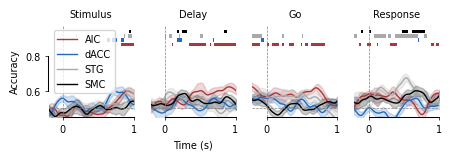

In [8]:
hue_order = ['AIC', 'dACC', 'STG','SMC']
# roi_colors = dict(zip(hue_order, [insula_color, smc_color, stg_color]))

hemis = ['Left']
phases = ['Stimulus','Delay','Go','Response']

fig, axes = plt.subplots(1, len(phases), figsize=(3.2*len(phases)*cm, 3*len(hemis)*cm))

time_arr = scores['time'].unique()
time_arr.sort()

ymax, pad, bar_h = 0.85, 0.01, 0.02
chance = 1/2
ymin = 0.45

colors = [red, blue, 'darkgray','black']

for j, phase in enumerate(phases):
    ax = axes[j]
    
    legend = True if j == 0 else False
    
    subset = scores[(scores.phase == phase) & (scores.hemi == hemi)]
    sns.lineplot(
        data=subset,
        x='time', y='accuracy', hue='roi',
        palette=colors, hue_order=hue_order,
        lw=1,
        ax=ax, legend=legend
    )
    
    # significant cluster（每个 roi 一个 bar）
    for k, roi in enumerate(hue_order):
        roi_data = subset[(subset.roi == roi) & (subset.fold == 0)].sort_values('time')
        if roi_data.empty:
            continue
        mask = (roi_data['p_value'].values < 0.05)
        offset = k * (bar_h + 0.005)
        
        if mask.any():
            ax.fill_between(
                roi_data['time'].values,
                ymax + pad + offset,
                ymax + pad + bar_h + offset,
                where=mask,
                color=colors[k],
                alpha=1,
                step='mid',
                linewidth=0
            )

for j, phase in enumerate(phases):
    ax = axes[j]
    ax.tick_params(labelsize=7, width=0.5, length=2)
    plt.setp(ax.spines.values(), linewidth=0.75)
    ax.axvline(x=0, color='gray', linestyle='--', lw=0.5)
    ax.axhline(y=chance, color='gray', linestyle='--', lw=0.5)
    ax.set_xlim(-0.2, 1)
    ax.set_ylim(ymin, ymax + pad + len(hue_order)*(bar_h + 0.005) + 0.02)
    ax.set_xlabel('')
    ax.set_ylabel('')
    
    # 右列去掉 y 轴
    if j == 1:
        ax.set_yticks([])
        ax.spines['left'].set_visible(False)
    
    # 顶行加标题
    ax.set_title(phase.capitalize(), fontsize=7)
    
    # 左列加 hemi 标签
    if j == 0:
        ax.set_ylabel('Accuracy', fontsize=7)

axes[1].set_xlabel('Time (s)', fontsize=7)
axes[0].legend(fontsize=7)

for ax in fig.axes:
    sns.despine(ax=ax, trim=True, offset=0.2)

# remove y spine for rightmost axes
for ax in axes[1:].flatten():
    ax.spines['left'].set_visible(False)
    ax.set_yticks([])
    ax.set_ylabel('')
    

# fig.savefig(f'../img/fig3/fig3_time_decode_{task}_{ref}_{desc}.svg', dpi=300, bbox_inches='tight')
plt.show()

In [9]:
# load decoding channels
LEXICAL_PATH = '/cwork/ns458/BIDS-1.0_LexicalDecRepDelay/BIDS/derivatives'

phase = 'Response'

decoding_pts = BIDSPath(
    root=os.path.join(LEXICAL_PATH, 'decoding(bipolar)'),
    processing=phase,
    extension='.h5',
    check=False,
)

pick_coord = []

for roi in hue_order:
    roi_pt = decoding_pts.update(subject=f'{roi}l').match()[0]
    with h5py.File(roi_pt, 'r') as f:
        ch = [c.decode() for c in f['channel'][:]]
        
        df = coords.copy()[coords.channel.isin(ch)]
        df['roi'] = roi
        pick_coord.append(df)
        
pick_coord = pd.concat(pick_coord)
pick_coord.head()

,channel,mask,roi,hemi,subject,description,task,phase,modality,label,x,y,z
16,D0047_LI5-6,False,AIC,L,D0047,Decision,LexicalDelay,Audio,sound,ctx_lh_S_circular_insula_sup,-37.102721,5.539169,3.773575
2816,D0047_LI5-6,True,AIC,L,D0047,Decision,LexicalDelay,Audio,sound,ctx_lh_S_circular_insula_sup,-37.102721,5.539169,3.773575
16,D0047_LI5-6,False,AIC,L,D0047,Repeat,LexicalDelay,Audio,sound,ctx_lh_S_circular_insula_sup,-37.102721,5.539169,3.773575
2752,D0047_LI5-6,True,AIC,L,D0047,Repeat,LexicalDelay,Audio,sound,ctx_lh_S_circular_insula_sup,-37.102721,5.539169,3.773575
14,D0047_LI5-6,False,AIC,L,D0047,Decision,LexicalDelay,Delay,sound,ctx_lh_S_circular_insula_sup,-37.102721,5.539169,3.773575


2026-03-10 14:36:28.877 (  96.319s) [    7F3C39B21740]vtkXOpenGLRenderWindow.:1416  WARN| bad X server connection. DISPLAY=


Reading labels from parcellation...
   read 75 labels from /cwork/ns458/ECoG_Recon/fsaverage/label/lh.aparc.a2009s.annot


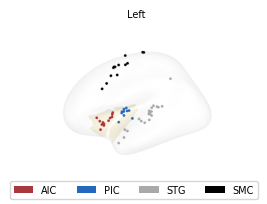

In [10]:
import numpy as np
import pyvista as pv
import matplotlib.pyplot as plt
from mne.viz import Brain
from scipy.spatial import cKDTree


# ROI 颜色：和 decoding 图保持一致
roi_colors = dict(zip(hue_order, colors))

# 只画左半球电极
pick_coord_lh = pick_coord[pick_coord["hemi"].isin(["L", "lh", "Left"])].copy()
if pick_coord_lh.empty:
    pick_coord_lh = pick_coord[pick_coord["x"] < 0].copy()

cord = pick_coord_lh[["x", "y", "z"]].values
rois = pick_coord_lh["roi"].values

# 加载左半球表面：pial -> inflated（把电极贴到 inflated 上）
lh_pial_path = f"{recon_dir}/fsaverage/surf/lh.pial"
lh_infl_path = f"{recon_dir}/fsaverage/surf/lh.inflated"
lh_coords_pial, _ = mne.read_surface(lh_pial_path)
lh_coords_infl, _ = mne.read_surface(lh_infl_path)
lh_tree = cKDTree(lh_coords_pial)

_, lh_indices = lh_tree.query(cord)
cord_on_infl = lh_coords_infl[lh_indices]

# 创建 inflated 左脑
lh_brain = Brain(
    "fsaverage",
    subjects_dir=recon_dir,
    surf="inflated",
    hemi="lh",
    background="white",
    show=False,
    cortex=(0.95, 0.95, 0.95),
    alpha=0.1,
    size=(600 * cm, 600 * cm),
)

labels = mne.read_labels_from_annot(
    "fsaverage",
    parc="aparc.a2009s",
    hemi="lh",
    subjects_dir=recon_dir,
)
insula_labels = [lab for lab in labels if "insul" in lab.name.lower()]
for lab in insula_labels:
    lh_brain.add_label(lab, borders=False, color=insula_color, alpha=0.4)

# 统一大小，不做大小调整
point_size = 25

# 按 ROI 上色
for roi in hue_order:
    roi_mask = rois == roi
    if not roi_mask.any():
        continue

    cloud = pv.PolyData(cord_on_infl[roi_mask])
    lh_brain._renderer.plotter.add_mesh(
        cloud,
        render_points_as_spheres=True,
        point_size=point_size,
        color=roi_colors[roi],
        lighting=False,
        smooth_shading=False,
        opacity=1,
    )

lh_brain.show_view(view="lateral", distance=400)
lh_brain._renderer.plotter.window_size = [1400, 1400]

fig, ax = plt.subplots(1, 1, figsize=(5 * cm, 5 * cm))
ax.imshow(lh_brain.screenshot(mode="rgb"))
ax.axis("off")
ax.set_title("Left", fontsize=7)

from matplotlib.patches import Patch

legend_elements = [Patch(facecolor=roi_colors[roi], label=roi) for roi in hue_order]
fig.legend(handles=legend_elements, loc="lower center", ncol=len(hue_order), fontsize=7)

lh_brain.close()
# fig.savefig(f'../img/fig3/fig3_{task}_spatial.svg', dpi=300, bbox_inches='tight')
plt.show()

# Cross Decode

In [ ]:
import h5py
import numpy as np
import pandas as pd
from tqdm import tqdm
from scipy.ndimage import gaussian_filter
from mne_bids import BIDSPath

ref = 'bipolar'
task = 'LexicalDelay'
decode_type = 'lexicality'

result_path = BIDSPath(
    datatype=f'(cross)(generalized){decode_type}',
    root=f'../results/{task}(roi)({ref})',
    suffix='highgamma',
    check=False
)

full_path = result_path.match()

scores = []

for path in tqdm(full_path, desc="Loading cached 2D results"):
    with h5py.File(path, 'r') as mat:
        # 读取原始数据
        accuracy = mat['scores'][()] 
        train_time = mat['train_time'][()]
        test_time = mat['test_time'][()]
        
        p_map = mat['p_values_cluster'][()] 
        
        # 只保留给 dataframe 平滑用的 baseline_mean
        baseline = mat['baseline'][()]

    n_train, n_test, n_fold = accuracy.shape
    baseline_mean = baseline.mean(axis=3)
        
    # [为了展示的热力图平滑]
    sigma = 1
    accuracy_smooth = gaussian_filter(accuracy, sigma=(sigma, sigma, 0), mode="nearest")
    
    Ttrain, Ttest = np.meshgrid(train_time, test_time, indexing='ij')
    
    df_acc = pd.DataFrame(accuracy_smooth.reshape(-1, n_fold), columns=range(n_fold))
    df_acc['train_time'] = Ttrain.flatten()
    df_acc['test_time'] = Ttest.flatten()
    df_acc = df_acc.melt(id_vars=['train_time', 'test_time'], var_name='fold', value_name='accuracy')

    # [不需要计算，直接把读出的 p_map 装表]
    df_p = pd.DataFrame({
        'train_time': Ttrain.flatten(),
        'test_time': Ttest.flatten(),
        'p_value': p_map.reshape(-1) # 直接对接后台刷入结果
    })
    
    # [依然把 baseline 也挂上去，供你在画图时过滤用]
    df_base = pd.DataFrame({
        'train_time': Ttrain.flatten(),
        'test_time': Ttest.flatten(),
        'baseline': baseline_mean.mean(axis=2).reshape(-1) 
    })
    
    df = df_acc.merge(df_p, on=['train_time', 'test_time'], how='left')
    df = df.merge(df_base, on=['train_time', 'test_time'], how='left')

    # 添加元信息
    hemi = 'Left' if path.subject[-1] == 'l' else 'Right'
    if '2' in path.description:
        train_on, test_on = path.description.split('2')
    else:
        train_on, test_on = path.description, path.description
        
    df['roi'] = path.subject
    df['phase'] = path.processing
    df['hemi'] = hemi
    df['train_on'] = train_on
    df['test_on'] = test_on
    df['datatype'] = path.datatype.replace('(cross)(generalized)', '')
    df['band'] = path.suffix

    scores.append(df)

scores = pd.concat(scores, ignore_index=True)
scores.head()

Loading cached 2D results: 100%|██████████| 72/72 [02:04<00:00,  1.73s/it]


,train_time,test_time,fold,accuracy,p_value,baseline,roi,phase,hemi,train_on,test_on,datatype,band
0,-0.8,-0.80,0,0.502276,1.0,0.503272,AICl,Delay,Left,Decision,Decision,lexicality,highgamma
1,-0.8,-0.78,0,0.510263,1.0,0.501353,AICl,Delay,Left,Decision,Decision,lexicality,highgamma
2,-0.8,-0.76,0,0.511446,1.0,0.489790,AICl,Delay,Left,Decision,Decision,lexicality,highgamma
3,-0.8,-0.74,0,0.504228,1.0,0.489621,AICl,Delay,Left,Decision,Decision,lexicality,highgamma
4,-0.8,-0.72,0,0.487768,1.0,0.490772,AICl,Delay,Left,Decision,Decision,lexicality,highgamma


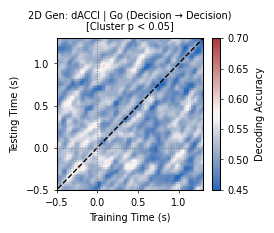

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.ndimage

def plot_merged_2d_generalization(df, roi, phase, train_on, test_on):
    # 1. 精确过滤关注的数据切片
    sub_df = df[(df.roi == roi) & 
                (df.phase == phase) & 
                (df.train_on == train_on) & 
                (df.test_on == test_on)].copy()
                
    if len(sub_df) == 0:
        print(f"No data found for {roi} - {phase} ({train_on} -> {test_on})")
        return
        
    # 2. 从 df 重建 2D 矩阵 (处理时间轴和 fold)
    # accuracy 和 baseline 都按 fold 计算均值
    
    acc_map = sub_df.groupby(['train_time', 'test_time'])['accuracy'].mean().unstack().values
    
    # 获取 p_value
    p_map = sub_df.groupby(['train_time', 'test_time'])['p_value'].mean().unstack().values
    
    # 自动兼容：如果表里有 baseline 就用 baseline，如果没有就直接用 0.5 (随机概率)
    if 'baseline' in sub_df.columns:
        base_map = sub_df.groupby(['train_time', 'test_time'])['baseline'].mean().unstack().values
    else:
        # 稳妥起见，设为 0.51，只要强于 51% 且 p<0.05 就认为是正区红斑
        base_map = np.ones_like(acc_map) * 0.5
    
    train_times = sorted(sub_df.train_time.unique())
    test_times = sorted(sub_df.test_time.unique())
    
    # --- 核心修复区 --- 
    # 只抓取 p<0.05 且 准确率高于底线的（去除蓝色坑洼）
    sig_mask = (p_map < 0.05) & (acc_map > base_map)
    
    # 空间连通域过滤：滤掉面积太小、零星的一两个散点 (至少 5 个像素)
    labeled_array, num_features = scipy.ndimage.label(sig_mask)
    min_cluster_size = 5 
    filtered_mask = np.zeros_like(sig_mask)
    for lbl in range(1, num_features + 1):
        if np.sum(labeled_array == lbl) >= min_cluster_size:
            filtered_mask[labeled_array == lbl] = 1

    # 开始作图
    fig, ax = plt.subplots(figsize=(6*cm, 5*cm))
    
    # pcolormesh 要求 T 转置矩阵
    im = ax.pcolormesh(train_times, test_times, acc_map.T, cmap='vlag', 
    vmin=0.45, vmax=0.7, shading='auto', rasterized=True)
    
    ax.set_xlim(-0.5, 1.3)
    ax.set_ylim(-0.5, 1.3)

    # 强制让 X 轴和 Y 轴只显示固定的 0.5 间隔刻度
    ticks = np.arange(-0.5, 1.5, 0.5)
    ax.set_xticks(ticks)
    ax.set_yticks(ticks)
    
    # 画对角线（Train == Test）
    ax.plot([train_times[0], train_times[-1]], [test_times[0], test_times[-1]], 
            color='black', linestyle='--', linewidth=1)
            
    # 叠加显著区黑圈等高线
    if np.any(filtered_mask):
        # 轮廓线的平滑度压低，让它更紧贴真实的方块边缘，而不是像墨汁一样化开
        mask_smoothed = scipy.ndimage.gaussian_filter(filtered_mask.astype(float), sigma=0.5)
        ax.contour(train_times, test_times, mask_smoothed.T, levels=[0.5], colors='black', linewidths=1)
        
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('Decoding Accuracy', fontsize=7)
    cbar.ax.tick_params(labelsize=7, width=0.5, length=2)
    plt.setp(cbar.ax.spines.values(), linewidth=0.75)
    
    ax.set_title(f"2D Gen: {roi} | {phase} ({train_on} → {test_on})\n[Cluster p < 0.05]", fontsize=7)
    ax.set_xlabel('Training Time (s)',fontsize=7)
    ax.set_ylabel('Testing Time (s)', fontsize=7)
    
    ax.tick_params(labelsize=7, width=0.5, length=2)
    plt.setp(ax.spines.values(), linewidth=0.75)

    # 原点辅线
    if 0 >= train_times[0] and 0 <= train_times[-1]:
        ax.axvline(x=0, color='gray', linestyle=':', linewidth=0.75)
    if 0 >= test_times[0] and 0 <= test_times[-1]:
        ax.axhline(y=0, color='gray', linestyle=':', linewidth=0.75)
        
    return fig

roi = 'dACCl'
train_on = 'Decision'
test_on = 'Decision'
phase = 'Go'

fig = plot_merged_2d_generalization(scores, roi=roi, phase=phase, train_on=train_on, test_on=test_on)
fig.savefig(f'../img/fig4/raw_{roi}_{phase}_{train_on}_{train_on}.svg', dpi=300, bbox_inches='tight')

Skipping SMCl - No data.
Skipping STGl - No data.
Skipping PICl - No data.


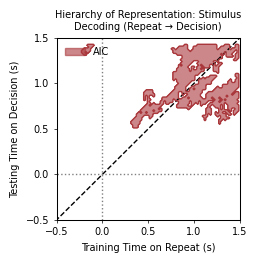

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.ndimage
import matplotlib.patches as mpatches

# 定义学术界常用的 cm 转 inch
cm = 1/2.54

def plot_overlay_roi_clusters(df, phase='Delay', train_on='Repeat', test_on='Decision'):
    """
    将多个 ROI 的 Significant Clusters 叠在同一张图上，使用半透明填充和描边。
    风格移植：使用莫兰迪高级配色、细化坐标轴、0.5秒跨度刻度，不使用额外平滑。
    """
    # 移植新的现代莫兰迪配色，保留 0.3 透明度
    rois_to_plot = {
        'AICl': {'color': red, 'alpha': 0.6, 'label': 'AIC'},
        'SMCl': {'color': 'black', 'alpha': 0.2, 'label': 'SMC'},
        'STGl': {'color': 'gray', 'alpha': 0.2, 'label': 'STG'},
        'PICl': {'color': blue, 'alpha': 0.6, 'label': 'PIC'}
    }
    
    # 使用和高级版一样的图表大小 (按 cm 控制更精确)
    fig, ax = plt.subplots(figsize=(6*cm, 6*cm))
    
    # 获取通用的时间轴
    tmp_df = df[(df.phase == phase) & (df.train_on == train_on) & (df.test_on == test_on)]
    if len(tmp_df) == 0:
        print("No data found for this condition!")
        return
        
    train_times = sorted(tmp_df.train_time.unique())
    test_times = sorted(tmp_df.test_time.unique())
    
    Ttrain, Ttest = np.meshgrid(train_times, test_times, indexing='ij')
    
    # 绘制基础网格和对称线
    ax.plot([train_times[0], train_times[-1]], [test_times[0], test_times[-1]], 
            color='black', linestyle='--', linewidth=1)
    if 0 >= train_times[0] and 0 <= train_times[-1]:
        ax.axvline(x=0, color='gray', linestyle=':', linewidth=1)
    if 0 >= test_times[0] and 0 <= test_times[-1]:
        ax.axhline(y=0, color='gray', linestyle=':', linewidth=1)

    legend_patches = []
    
    for roi, style in rois_to_plot.items():
        # 抓取当前 ROI 的切片
        sub_df = df[(df.roi == roi) & 
                    (df.phase == phase) & 
                    (df.train_on == train_on) & 
                    (df.test_on == test_on)].copy()
                    
        if len(sub_df) == 0:
            print(f"Skipping {roi} - No data.")
            continue
            
        acc_map = sub_df.groupby(['train_time', 'test_time'])['accuracy'].mean().unstack().values
        p_map = sub_df.groupby(['train_time', 'test_time'])['p_value'].mean().unstack().values
        
        # 获取 base_map
        if 'baseline' in sub_df.columns:
            base_map = sub_df.groupby(['train_time', 'test_time'])['baseline'].mean().unstack().values
        else:
            base_map = np.ones_like(acc_map) * 0.5
            
        # 1. 严格过滤：显著 P 值 且 准确率大于基线
        sig_mask = (p_map < 0.05) & (acc_map > base_map)
        
        # 2. 空间连通域过滤：滤掉面积太小、零星的散点 (至少 5 个像素)
        labeled_array, num_features = scipy.ndimage.label(sig_mask)
        filtered_mask = np.zeros_like(sig_mask)
        for lbl in range(1, num_features + 1):
            if np.sum(labeled_array == lbl) >= 5:
                filtered_mask[labeled_array == lbl] = 1
                
        if not np.any(filtered_mask):
            print(f"[{roi}] No significant clusters survived.")
            continue
            
        # 3. 画出这个 ROI 的领地！(使用原始未平滑的 mask)
        # a. 填充半透明色块
        ax.contourf(train_times, test_times, filtered_mask.T, 
                    levels=[0.5, 1.5], colors=[style['color']], alpha=style['alpha'])
        # b. 描出实心边界线，让范围更加骨感清晰 (和高级版一样使用 1.0 的细线宽)
        ax.contour(train_times, test_times, filtered_mask.T, 
                   levels=[0.5], colors=[style['color']], linewidths=1.0)
                   
        # 添加图例
        legend_patches.append(mpatches.Patch(color=style['color'], alpha=style['alpha'], label=style['label']))

    # --- 移植高级排版风格 ---
    ax.set_title(f"Hierarchy of Representation: {phase}\nDecoding ({train_on} → {test_on})", 
                 fontsize=7)
    ax.set_xlabel(f'Training Time on {train_on} (s)', fontsize=7)
    ax.set_ylabel(f'Testing Time on {test_on} (s)', fontsize=7)
    
    # 固定范围
    ax.set_xlim(-0.5, 1.5)
    ax.set_ylim(-0.5, 1.5)
    
    ticks = np.arange(-0.5, 1.6, 0.5)
    ax.set_xticks(ticks)
    ax.set_yticks(ticks)

    ax.tick_params(labelsize=7, width=0.5, length=2)
    plt.setp(ax.spines.values(), linewidth=0.75)
    
    if legend_patches:
        ax.legend(handles=legend_patches, loc='upper left', frameon=False, fontsize=7)
        
    return fig

train_on = 'Repeat'
test_on = 'Decision'
phase = 'Stimulus'

fig = plot_overlay_roi_clusters(scores, phase=phase, train_on=train_on, test_on=test_on)
fig.savefig(f'../img/fig4/overlay_{phase}_{train_on}_{test_on}.svg', dpi=300, bbox_inches='tight')

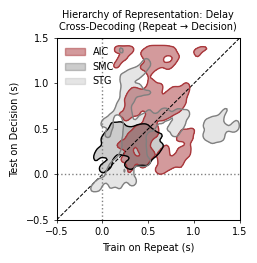

In [59]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.ndimage
import matplotlib.patches as mpatches

def plot_overlay_roi_clusters_smoothed(df, phase='Delay', train_on='Repeat', test_on='Decision'):
    """
    将多个 ROI 的 Significant Clusters 叠在同一张图上，
    加入了高斯平滑层，让不规则的边缘变成漂亮的云团状，适合文章和汇报展示。
    """
    # 我们要展示的三个核心 ROI 和它们对应的颜色
    rois_to_plot = {
        'AICl': {'color': red, 'alpha': 0.5, 'label': 'AIC'},
        'SMCl': {'color': 'black', 'alpha': 0.2, 'label': 'SMC'},
        'STGl': {'color': 'gray', 'alpha': 0.2, 'label': 'STG'}
    }
    
    fig, ax = plt.subplots(figsize=(6*cm, 6*cm))
    
    tmp_df = df[(df.phase == phase) & (df.train_on == train_on) & (df.test_on == test_on)]
    if len(tmp_df) == 0:
        print("No data found for this condition!")
        return
        
    train_times = sorted(tmp_df.train_time.unique())
    test_times = sorted(tmp_df.test_time.unique())
    
    # 绘制基础网格
    ax.plot([train_times[0], train_times[-1]], [test_times[0], test_times[-1]], 
            color='black', linestyle='--', linewidth=0.75)
    if 0 >= train_times[0] and 0 <= train_times[-1]:
        ax.axvline(x=0, color='gray', linestyle=':', linewidth=1)
    if 0 >= test_times[0] and 0 <= test_times[-1]:
        ax.axhline(y=0, color='gray', linestyle=':', linewidth=1)

    legend_patches = []
    
    for roi, style in rois_to_plot.items():
        sub_df = df[(df.roi == roi) & 
                    (df.phase == phase) & 
                    (df.train_on == train_on) & 
                    (df.test_on == test_on)].copy()
                    
        if len(sub_df) == 0:
            continue
            
        acc_map = sub_df.groupby(['train_time', 'test_time'])['accuracy'].mean().unstack().values
        p_map = sub_df.groupby(['train_time', 'test_time'])['p_value'].mean().unstack().values
        
        if 'baseline' in sub_df.columns:
            base_map = sub_df.groupby(['train_time', 'test_time'])['baseline'].mean().unstack().values
        else:
            base_map = np.ones_like(acc_map) * 0.65
            
        # 1. 稍微对输入数据进行一点点柔化，消除孤立尖刺噪声
        acc_smoothed = scipy.ndimage.gaussian_filter(acc_map, sigma=0.2)
        p_smoothed = scipy.ndimage.gaussian_filter(p_map, sigma=0.2)
            
        # 2. 生成过滤掩码
        sig_mask = (p_smoothed < 0.05) & (acc_smoothed > base_map)
        
        # 3. 滤除细碎的小岛屿 (连通域剔除)
        labeled_array, num_features = scipy.ndimage.label(sig_mask)
        filtered_mask = np.zeros_like(sig_mask, dtype=float)
        for lbl in range(1, num_features + 1):
            if np.sum(labeled_array == lbl) >= 4:  
                filtered_mask[labeled_array == lbl] = 1.0
                
        if not np.any(filtered_mask):
            print(f"[{roi}] No large clusters survived smoothing.")
            continue
            
        # 4. 终极视觉平滑：对二值化 Mask 进行大尺度平滑，让它变成云朵形状
        final_smooth_mask = scipy.ndimage.gaussian_filter(filtered_mask, sigma=1.5)
        
        # 填充半透明色块 (我们以 0.5 概率为等高线边界)
        ax.contourf(train_times, test_times, final_smooth_mask.T, 
                    levels=[0.4, 1.5], colors=[style['color']], alpha=style['alpha'])
        # 画平滑流畅的丝滑边界
        ax.contour(train_times, test_times, final_smooth_mask.T, 
                   levels=[0.4], colors=[style['color']], linewidths=1.0)
                   
        legend_patches.append(mpatches.Patch(color=style['color'], alpha=style['alpha'], label=style['label']))

    ax.set_title(f"Hierarchy of Representation: {phase}\nCross-Decoding ({train_on} → {test_on})", 
                fontsize=7)
    ax.set_xlabel(f'Train on {train_on} (s)', fontsize=7)
    ax.set_ylabel(f'Test on {test_on} (s)', fontsize=7)
    ax.set_xlim(-0.5, 1.5)
    ax.set_ylim(-0.5, 1.5)

    ticks = np.arange(-0.5, 1.6, 0.5)
    ax.set_xticks(ticks)
    ax.set_yticks(ticks)

    ax.tick_params(labelsize=7, width=0.5, length=2)
    plt.setp(ax.spines.values(), linewidth=0.75)
    
    if legend_patches:
        ax.legend(handles=legend_patches, loc='upper left', frameon=False, fontsize=7)
    plt.show()

plot_overlay_roi_clusters_smoothed(scores, phase='Delay', train_on='Repeat', test_on='Decision')

### Spatial

In [22]:
# load decoding channels
LEXICAL_PATH = '/cwork/ns458/BIDS-1.0_LexicalDecRepDelay/BIDS/derivatives'

phase = 'Response'

decoding_pts = BIDSPath(
    root=os.path.join(LEXICAL_PATH, 'decoding(intersection)(bipolar)'),
    processing=phase,
    extension='.h5',
    check=False,
)

pick_coord = []
colors = [red, blue, 'darkgray','black']

hue_order = ['AIC', 'PIC', 'STG','SMC']


for roi in hue_order:
    roi_pt = decoding_pts.update(subject=f'{roi}l').match()[0]
    with h5py.File(roi_pt, 'r') as f:
        ch = [c.decode() for c in f['channel'][:]]
        
        df = coords.copy()[coords.channel.isin(ch)]
        df['roi'] = roi
        pick_coord.append(df)
        
pick_coord = pd.concat(pick_coord)
pick_coord.head()

PermissionError: [Errno 13] Permission denied: '/cwork/ns458/BIDS-1.0_LexicalDecRepDelay/BIDS/derivatives/decoding(intersection)(bipolar)'

2026-03-02 19:47:42.280 (1210.498s) [    7FF54639A1C0]vtkXOpenGLRenderWindow.:1416  WARN| bad X server connection. DISPLAY=
VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card0: Permission denied

2026-03-02 19:47:42.489 (1210.707s) [    7FF54639A1C0] vtkEGLRenderWindow.cxx:353   WARN| vtkEGLRenderWindow (0x49b441a0): EGL device index: 0 could not be initialized. Trying other devices...
VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card0: Permission denied

2026-03-02 19:47:42.735 (1210.953s) [    7FF54639A1C0] vtkEGLRenderWindow.cxx:353   WARN| vtkEGLRenderWindow (0x49b441a0): EGL device index: 0 could not be initialized. Trying other devices...
VMware: No 3D 

Reading labels from parcellation...
   read 75 labels from /cwork/ns458/ECoG_Recon/fsaverage/label/lh.aparc.a2009s.annot


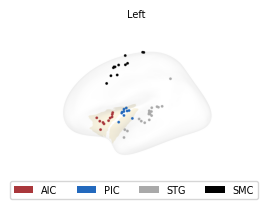

In [13]:
import numpy as np
import pyvista as pv
import matplotlib.pyplot as plt
from mne.viz import Brain
from scipy.spatial import cKDTree


# ROI 颜色：和 decoding 图保持一致
roi_colors = dict(zip(hue_order, colors))

# 只画左半球电极
pick_coord_lh = pick_coord[pick_coord["hemi"].isin(["L", "lh", "Left"])].copy()
if pick_coord_lh.empty:
    pick_coord_lh = pick_coord[pick_coord["x"] < 0].copy()

cord = pick_coord_lh[["x", "y", "z"]].values
rois = pick_coord_lh["roi"].values

# 加载左半球表面：pial -> inflated（把电极贴到 inflated 上）
lh_pial_path = f"{recon_dir}/fsaverage/surf/lh.pial"
lh_infl_path = f"{recon_dir}/fsaverage/surf/lh.inflated"
lh_coords_pial, _ = mne.read_surface(lh_pial_path)
lh_coords_infl, _ = mne.read_surface(lh_infl_path)
lh_tree = cKDTree(lh_coords_pial)

_, lh_indices = lh_tree.query(cord)
cord_on_infl = lh_coords_infl[lh_indices]

# 创建 inflated 左脑
lh_brain = Brain(
    "fsaverage",
    subjects_dir=recon_dir,
    surf="inflated",
    hemi="lh",
    background="white",
    show=False,
    cortex=(0.95, 0.95, 0.95),
    alpha=0.1,
    size=(600 * cm, 600 * cm),
)

labels = mne.read_labels_from_annot(
    "fsaverage",
    parc="aparc.a2009s",
    hemi="lh",
    subjects_dir=recon_dir,
)
insula_labels = [lab for lab in labels if "insul" in lab.name.lower()]
for lab in insula_labels:
    lh_brain.add_label(lab, borders=False, color=insula_color, alpha=0.4)

# 统一大小，不做大小调整
point_size = 25

# 按 ROI 上色
for roi in hue_order:
    roi_mask = rois == roi
    if not roi_mask.any():
        continue

    cloud = pv.PolyData(cord_on_infl[roi_mask])
    lh_brain._renderer.plotter.add_mesh(
        cloud,
        render_points_as_spheres=True,
        point_size=point_size,
        color=roi_colors[roi],
        lighting=False,
        smooth_shading=False,
        opacity=1,
    )

lh_brain.show_view(view="lateral", distance=400)
lh_brain._renderer.plotter.window_size = [1400, 1400]

fig, ax = plt.subplots(1, 1, figsize=(5 * cm, 5 * cm))
ax.imshow(lh_brain.screenshot(mode="rgb"))
ax.axis("off")
ax.set_title("Left", fontsize=7)

from matplotlib.patches import Patch

legend_elements = [Patch(facecolor=roi_colors[roi], label=roi) for roi in hue_order]
fig.legend(handles=legend_elements, loc="lower center", ncol=len(hue_order), fontsize=7)

lh_brain.close()
fig.savefig(f'../img/fig3/fig3_{task}_spatial_intersection.svg', dpi=300, bbox_inches='tight')
plt.show()

## Spatial Pattern

In [31]:
ref = 'bipolar'
task = 'LexicalDelay' # 记得根据你的实际情况切换
decode_type = 'lexicality'

result_path = BIDSPath(
    datatype=f'(pattern){decode_type}',
    root=f'../results/{task}(roi)({ref})',
    suffix='highgamma',
    check=False
)

full_path = result_path.match()
patterns_list = []

for path in tqdm(full_path, desc="Loading Spatial Patterns"):
    with h5py.File(path, 'r') as mat:
        # patterns shape: (n_times, n_channels, window_samples)
        patterns = mat['patterns'][()] 
        time_points = mat['time_points'][()]
        
        # 提取刚刚我们修复好的真正的 Channel Names
        raw_channels = mat['channels'][()]
        # HDF5 里存的是 byte string，需要 decode 解码成普通的 utf-8 字符串
        channels = [ch.decode('utf-8') for ch in raw_channels]
        
    n_times, n_channels, window_samples = patterns.shape
    
    # 【降维处理】提取 200ms 时间窗内该通道激活的绝对值均值 (代表参与度大小)
    patterns_mag = np.abs(patterns).mean(axis=2) # shape: (n_times, n_channels)
    
    # 用真正的 Channel 名字作为列名
    df_patt = pd.DataFrame(patterns_mag, columns=channels)
    df_patt['time'] = time_points
    # 宽表变长表
    df_patt = df_patt.melt(id_vars=['time'], var_name='channel', value_name='pattern_weight')

    # 添加元信息
    hemi = 'Left' if path.subject[-1] == 'l' else 'Right'
    df_patt['roi'] = path.subject[:-1] if path.subject[-1] in ['l', 'r'] else path.subject
    df_patt['roi_raw'] = path.subject 
    df_patt['phase'] = path.processing
    df_patt['hemi'] = hemi
    df_patt['description'] = path.description
    df_patt['datatype'] = path.datatype.replace('(pattern)', '')
    df_patt['band'] = path.suffix

    patterns_list.append(df_patt)

patterns = pd.concat(patterns_list, ignore_index=True)
patterns.head()

Loading Spatial Patterns:   0%|          | 0/8 [00:00<?, ?it/s]

Loading Spatial Patterns: 100%|██████████| 8/8 [00:00<00:00, 22.84it/s]


,time,channel,pattern_weight,roi,roi_raw,phase,hemi,description,datatype,band
0,0.0,D0047_LI5-6,0.162144,AIC,AICl,Delay,Left,Decision,lexicality,highgamma
1,0.1,D0047_LI5-6,0.140509,AIC,AICl,Delay,Left,Decision,lexicality,highgamma
2,0.2,D0047_LI5-6,0.099427,AIC,AICl,Delay,Left,Decision,lexicality,highgamma
3,0.3,D0047_LI5-6,0.188663,AIC,AICl,Delay,Left,Decision,lexicality,highgamma
4,0.4,D0047_LI5-6,0.210842,AIC,AICl,Delay,Left,Decision,lexicality,highgamma


In [32]:
# 从你全局的 coords 表里，精准提取电极名字和对应的坐标
# 为了防止列名冲突或把一堆无用的列带过来，我们只取最核心的列
coord_subset = coords[['channel', 'x', 'y', 'z']].drop_duplicates()

# 将提取出来的 pattern 权重表与坐标表依据 'channel' 进行内连接
# 这样每个时间窗的这个电极都会对应获得一份它的 (x, y, z)
df_patterns_merged = pd.merge(
    patterns, 
    coord_subset, 
    on='channel', 
    how='left'  
)

df_patterns_merged.head()

,time,channel,pattern_weight,roi,roi_raw,phase,hemi,description,datatype,band,x,y,z
0,0.0,D0047_LI5-6,0.162144,AIC,AICl,Delay,Left,Decision,lexicality,highgamma,-37.102721,5.539169,3.773575
1,0.1,D0047_LI5-6,0.140509,AIC,AICl,Delay,Left,Decision,lexicality,highgamma,-37.102721,5.539169,3.773575
2,0.2,D0047_LI5-6,0.099427,AIC,AICl,Delay,Left,Decision,lexicality,highgamma,-37.102721,5.539169,3.773575
3,0.3,D0047_LI5-6,0.188663,AIC,AICl,Delay,Left,Decision,lexicality,highgamma,-37.102721,5.539169,3.773575
4,0.4,D0047_LI5-6,0.210842,AIC,AICl,Delay,Left,Decision,lexicality,highgamma,-37.102721,5.539169,3.773575


/hpc/home/ns458/coganlab/nanlinshi/tmp/ipykernel_2158853/3332136721.py:23: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('Reds')
VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card0: Permission denied

2026-03-02 20:18:48.603 (3076.821s) [    7FF54639A1C0] vtkEGLRenderWindow.cxx:353   WARN| vtkEGLRenderWindow (0x47eebe50): EGL device index: 0 could not be initialized. Trying other devices...
VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card0: Permission denied

2026-

Reading labels from parcellation...
   read 75 labels from /cwork/ns458/ECoG_Recon/fsaverage/label/lh.aparc.a2009s.annot


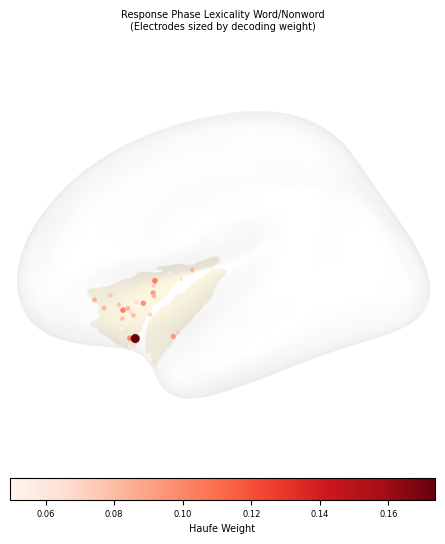

In [35]:
import numpy as np
import pyvista as pv
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from mne.viz import Brain
from scipy.spatial import cKDTree

# 1. 计算每个电极在所有时间窗内的平均 Pattern 权重
# 这里 df_patterns_merged 是上一步合并坐标产生的 DataFrame
subset = df_patterns_merged[
    (df_patterns_merged.description=='Repeat') &
    (df_patterns_merged.phase=='Response')
]
mean_patt_df = subset.groupby(['channel', 'x', 'y', 'z', 'roi'])['pattern_weight'].mean().reset_index()

# 为了视觉对比，把权重进行归一化处理 (0 到 1 之间)，用来映射颜色和大小
weights = mean_patt_df['pattern_weight'].values
norm_weights = (weights - np.min(weights)) / (np.max(weights) - np.min(weights) + 1e-9)

# 2. 映射颜色和气泡大小
# 使用 'Reds' 红色系热力图风格 (或 'viridis' 等)
cmap = cm.get_cmap('Reds')
node_colors = cmap(norm_weights)

# 给电极一个基准大小 (比如 20) 加上基于权重的动态缩放大小
min_size, max_size = 10, 30
node_sizes = min_size + norm_weights * (max_size - min_size)

# 只取左脑进行投射
mean_patt_df['norm_weight'] = norm_weights
mean_patt_df['size'] = node_sizes
mean_patt_df['color_rgba'] = list(node_colors)

# 如果你跑出来的数据只局限于 AICl，x 当然都小于 0
cord = mean_patt_df[["x", "y", "z"]].values

# 3. MNE 表面投射逻辑
lh_pial_path = f"{recon_dir}/fsaverage/surf/lh.pial"
lh_infl_path = f"{recon_dir}/fsaverage/surf/lh.inflated"
lh_coords_pial, _ = mne.read_surface(lh_pial_path)
lh_coords_infl, _ = mne.read_surface(lh_infl_path)
lh_tree = cKDTree(lh_coords_pial)

# 寻找最近点投射
_, lh_indices = lh_tree.query(cord)
cord_on_infl = lh_coords_infl[lh_indices]

# 4. 创建 3D 图形
lh_brain = Brain(
    "fsaverage",
    subjects_dir=recon_dir,
    surf="inflated",
    hemi="lh",
    background="white",
    show=False,
    cortex=(0.95, 0.95, 0.95),
    alpha=0.1,
    size=(600, 600), # 借用你之前的 cm 比例
)

# 涂上 Insula 的轮廓阴影底色以便参照
labels = mne.read_labels_from_annot("fsaverage", parc="aparc.a2009s", hemi="lh", subjects_dir=recon_dir)
insula_labels = [lab for lab in labels if "insul" in lab.name.lower()]
for lab in insula_labels:
    lh_brain.add_label(lab, borders=False, color=insula_color, alpha=0.4)

# 5. [核心修改]：把之前统一的 add_mesh 换成允许每个点有独立大小/颜色的高阶投射
# 由于原生 mne / pyvista add_mesh 的 point_size 只能传单一数字，
# 因此我们对每一个电极独立循环赋予它的大小和颜色 (因为点数量不多，性能绝对没问题)

for i, row_xyz in enumerate(cord_on_infl):
    # 用 PolyData 构建单个球体坐标源
    cloud = pv.PolyData(np.array([row_xyz]))
    
    # 获取属于该电极的专属大小与颜色
    s = mean_patt_df.iloc[i]['size']
    c = mean_patt_df.iloc[i]['color_rgba']
    
    lh_brain._renderer.plotter.add_mesh(
        cloud,
        render_points_as_spheres=True,
        point_size=s,            # <--- 动态权重大小
        color=c[:3],             # pyvista 接收 RGB，不接收 rgba
        lighting=False,
        smooth_shading=False,
        opacity=1.0,
    )

# 调整主视角
lh_brain.show_view(view="lateral", distance=400)
lh_brain._renderer.plotter.window_size = [1400, 1400]

# 6. 捕捉截图并绘制到 Matplotlib
fig, ax = plt.subplots(1, 1, figsize=(6, 6))
ax.imshow(lh_brain.screenshot(mode="rgb"))
ax.axis("off")
ax.set_title("Response Phase Lexicality Word/Nonword\n(Electrodes sized by decoding weight)", fontsize=7)

# （可选）添加 Colorbar 表示权重的热度映射
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=weights.min(), vmax=weights.max()))
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, orientation='horizontal', fraction=0.046, pad=0.04)
cbar.set_label('Haufe Weight', fontsize=7)
cbar.ax.tick_params(labelsize=6)

lh_brain.close()

# fig.savefig(f'../img/fig4/response_lexicality_weights_3d.svg', dpi=300, bbox_inches='tight')
plt.show()

# Decode Picture Naming Token

In [9]:
from scipy.ndimage import gaussian_filter1d

ref = 'bipolar'
task = 'PictureNaming'
decode_type = 'token'

result_path = BIDSPath(
    datatype=f'(decode)(resolved){decode_type}',
    root= f'../results/{task}(roi)({ref})',
    suffix='highgamma',
    check=False
)

full_path = result_path.match()

scores = []

for path in full_path:
    mat = h5py.File(path, 'r')
    # accuracy: (time, fold)
    accuracy = mat['accuracy'][()]
    # time: (time,)
    time = mat['time'][()]
    # p_value: (time,)
    p_value = mat['p_values'][()]
    # baseline: (time, fold, n_perm)
    baseline = mat['baseline'][()]
    mat.close()

    n_time, n_fold = accuracy.shape

    # ---- 1) baseline 在 perm 维度上平均 → (time, fold) ----
    baseline_mean = baseline.mean(axis=-1)  # shape: (time, fold)

    # ---- 2) 宽表：每列一个 fold（accuracy）----
    sigma = 1  # 单位：time 采样点数（不是秒）；你可以调 1~5 之类
    accuracy = gaussian_filter1d(accuracy, sigma=sigma, axis=0, mode="nearest")
    df_acc = pd.DataFrame(accuracy, index=time, columns=range(n_fold)).reset_index()
    df_acc = df_acc.rename(columns={'index': 'time'})

    # 宽表 baseline
    df_base = pd.DataFrame(baseline_mean, index=time, columns=range(n_fold)).reset_index()
    df_base = df_base.rename(columns={'index': 'time'})

    # ---- 3) 宽 → 长，显式保留 fold ----
    df_acc = df_acc.melt(
        id_vars='time',
        var_name='fold',
        value_name='accuracy'
    )  # (time * fold, 3)

    df_base = df_base.melt(
        id_vars='time',
        var_name='fold',
        value_name='baseline'
    )

    # 合并 accuracy 和 baseline（按 time, fold 对齐）
    df = df_acc.merge(df_base, on=['time', 'fold'], how='left')

    # ---- 4) p_value 只有 time 维度，就按 time merge ----
    df_p = pd.DataFrame({'time': time, 'p_value': p_value})
    df = df.merge(df_p, on='time', how='left')

    # ---- 5) 加上 path 的元信息 ----
    hemi = 'Left' if path.subject[-1]=='l' else 'Right'
    roi = path.subject[:-1]
    df['roi'] = roi
    df['phase'] = path.processing
    df['hemi'] = hemi
    df['description'] = path.description
    df['modality'] = path.recording
    df['datatype'] = path.datatype.replace('(decode)(resolving)', '')
    df['band'] = path.suffix

    scores.append(df)

scores = pd.concat(scores, ignore_index=True)
# scores = scores[scores.roi.isin(['INS','STG','SMC'])]
# rename
scores = scores[(scores.description=='Repeat') &
                (scores.modality=='image')]
scores.head()

,time,fold,accuracy,baseline,p_value,roi,phase,hemi,description,modality,datatype,band
0,-0.30,0,0.230378,0.273750,0.174129,AIC,Delay,Left,Repeat,image,(decode)(resolved)token,highgamma
1,-0.28,0,0.349686,0.256875,0.208955,AIC,Delay,Left,Repeat,image,(decode)(resolved)token,highgamma
2,-0.26,0,0.388912,0.230625,0.258706,AIC,Delay,Left,Repeat,image,(decode)(resolved)token,highgamma
3,-0.24,0,0.359219,0.225000,0.442786,AIC,Delay,Left,Repeat,image,(decode)(resolved)token,highgamma
4,-0.22,0,0.270125,0.258750,0.407960,AIC,Delay,Left,Repeat,image,(decode)(resolved)token,highgamma


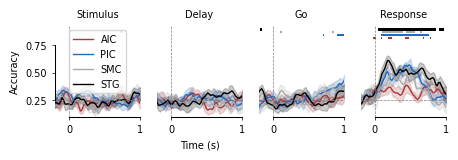

In [10]:
hue_order = ['AIC','PIC','SMC','STG']
# roi_colors = dict(zip(hue_order, [insula_color, smc_color, stg_color]))

hemis = ['Left']
phases = ['Stimulus','Delay','Go','Response']

fig, axes = plt.subplots(1, len(phases), figsize=(3.2*len(phases)*cm, 3*len(hemis)*cm))

time_arr = scores['time'].unique()
time_arr.sort()

ymax, pad, bar_h = 0.8, 0.01, 0.02
chance = 1/4
ymin = 0.1

colors = [red, blue, 'darkgray','black']

for j, phase in enumerate(phases):
    ax = axes[j]
    
    legend = True if j == 0 else False
    
    subset = scores[(scores.phase == phase) & (scores.hemi == hemi)]
    sns.lineplot(
        data=subset,
        x='time', y='accuracy', hue='roi',
        palette=colors, hue_order=hue_order,
        lw=1,
        ax=ax, legend=legend
    )
    
    # significant cluster（每个 roi 一个 bar）
    for k, roi in enumerate(hue_order):
        roi_data = subset[(subset.roi == roi) & (subset.fold == 0)].sort_values('time')
        if roi_data.empty:
            continue
        mask = (roi_data['p_value'].values < 0.05)
        offset = k * (bar_h + 0.005)
        
        if mask.any():
            ax.fill_between(
                roi_data['time'].values,
                ymax + pad + offset,
                ymax + pad + bar_h + offset,
                where=mask,
                color=colors[k],
                alpha=1,
                step='mid',
                linewidth=0
            )

for j, phase in enumerate(phases):
    ax = axes[j]
    ax.tick_params(labelsize=7, width=0.5, length=2)
    plt.setp(ax.spines.values(), linewidth=0.75)
    ax.axvline(x=0, color='gray', linestyle='--', lw=0.5)
    ax.axhline(y=chance, color='gray', linestyle='--', lw=0.5)
    ax.set_xlim(-0.2, 1)
    ax.set_ylim(ymin, ymax + pad + len(hue_order)*(bar_h + 0.005) + 0.02)
    ax.set_xlabel('')
    ax.set_ylabel('')
    
    # 右列去掉 y 轴
    if j == 1:
        ax.set_yticks([])
        ax.spines['left'].set_visible(False)
    
    # 顶行加标题
    ax.set_title(phase.capitalize(), fontsize=7)
    
    # 左列加 hemi 标签
    if j == 0:
        ax.set_ylabel('Accuracy', fontsize=7)

axes[1].set_xlabel('Time (s)', fontsize=7)
axes[0].legend(fontsize=7)

for ax in fig.axes:
    sns.despine(ax=ax, trim=True, offset=0.2)

# remove y spine for rightmost axes
for ax in axes[1:].flatten():
    ax.spines['left'].set_visible(False)
    ax.set_yticks([])
    ax.set_ylabel('')
    
# fig.savefig(f'../img/fig3/fig3_time_decode_{task}_{ref}_{desc}.svg', dpi=300, bbox_inches='tight')
plt.show()